# Customer Segmentation Notebook


LOADING DATASET

In [1]:
import pandas as pd
data=pd.read_csv("Mall_Customers.csv")

In [2]:
print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


THERE IS NO REQUIREMENTS OF DATA CLEANINIG FOR DATASET , SINCE THERE IS NO NULL VALUES IN THE LOADED DATASET 

In [3]:
X=data[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


# Elbow Method to find the best number of Clusters

In [4]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
print(wcss)

[269981.28, 186362.95600651755, 106348.37306211118, 73679.78903948836, 44448.45544793371, 40845.0821432953, 30273.394312070042, 28416.427684234375, 21850.165282585633, 20698.846431012596]


Graph Plotting for the ELBOW METHOD

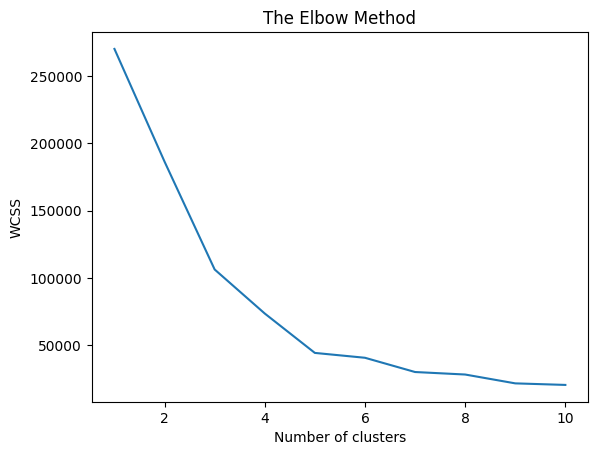

In [5]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

CHOOSING THE "n_clusters=5" from the observation of elbow method


# PIPELINE AND PREPROCESSING

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


ColumnTransformer

In [7]:
preprocess=ColumnTransformer(transformers=[('num', StandardScaler(), ['Annual Income (k$)', 'Spending Score (1-100)'])])

Pipeline
1.preprocessing
2.kmeans model



In [8]:
steps=[('preprocess', preprocess), ('model', KMeans(n_clusters=5))]
Pipeline(steps)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [9]:
from sklearn.metrics import silhouette_score
model=Pipeline(steps)
model_scores=silhouette_score(X,model.fit_predict(X))
print(model_scores)


0.5532176107575425


BY USING "n_clusters=5" GIVES MODEL_SCORES=0.553931997444648 

Attach cluster labels into tha dataset

In [10]:
data["cluster"]=model.fit_predict(X)
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        0  
1        1  
2        0  
3        1  
4        0  


Analyze clusters : 
compute averages per cluster

In [11]:
data.groupby("cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,23.000000,45.217391,26.304348,20.913043
1,23.090909,25.272727,25.727273,79.363636
2,164.371429,41.114286,88.200000,17.114286
3,162.000000,32.692308,86.538462,82.128205
4,86.320988,42.716049,55.296296,49.518519


In [12]:
lst=list(data["cluster"].to_list())
print(set(lst))

{0, 1, 2, 3, 4}


In [13]:
data.groupby("cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,23.000000,45.217391,26.304348,20.913043
1,23.090909,25.272727,25.727273,79.363636
2,164.371429,41.114286,88.200000,17.114286
3,162.000000,32.692308,86.538462,82.128205
4,86.320988,42.716049,55.296296,49.518519


THE MODEL HAS FORMED FIVE TYPES OF CLUSTERS [0,1,2,3,4]

CREATING A NEW COLUMN CALLED "INCOME" FOR BUSINESS MEANING

In [14]:
def declaration(x):
    if x==0:
        return "Rich but low SPENDERS"
    elif x==1:
        return "AVERAGE customers"
    elif x==2:
        return "Young and HIGH SPENDERS"
    elif x==3:
        return "PREMIUM CUSTOMERS"
    else:
        return "HIGH VALUE CUSTOMERS"
data["SEGMENTATION"]=data["cluster"].apply(declaration)
data["SEGMENTATION"]

0        Rich but low SPENDERS
1            AVERAGE customers
2        Rich but low SPENDERS
3            AVERAGE customers
4        Rich but low SPENDERS
                ...           
195          PREMIUM CUSTOMERS
196    Young and HIGH SPENDERS
197          PREMIUM CUSTOMERS
198    Young and HIGH SPENDERS
199          PREMIUM CUSTOMERS
Name: SEGMENTATION, Length: 200, dtype: str

In [15]:
data["SEGMENTATION"].value_counts()

SEGMENTATION
HIGH VALUE CUSTOMERS       81
PREMIUM CUSTOMERS          39
Young and HIGH SPENDERS    35
Rich but low SPENDERS      23
AVERAGE customers          22
Name: count, dtype: int64

In [16]:
data.groupby("SEGMENTATION").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),cluster
SEGMENTATION,,,,,
AVERAGE customers,23.090909,25.272727,25.727273,79.363636,1.0
HIGH VALUE CUSTOMERS,86.320988,42.716049,55.296296,49.518519,4.0
PREMIUM CUSTOMERS,162.000000,32.692308,86.538462,82.128205,3.0
Rich but low SPENDERS,23.000000,45.217391,26.304348,20.913043,0.0
Young and HIGH SPENDERS,164.371429,41.114286,88.200000,17.114286,2.0


SAVING THE PIPELINE

In [17]:
import joblib
joblib.dump(model,"customer_segmentation_model.pkl")

['customer_segmentation_model.pkl']